# K-Means++ Initialization

**K-means** partitions a point cloud $\{x_i\}_{i=1}^n \subset \mathbb{R}^d$ into $k$ clusters by minimising the **within-cluster sum of squares (WCSS)**:

$$
\min_{c_1,\ldots,c_k,\, z_1,\ldots,z_n} \sum_{i=1}^n \|x_i - c_{z_i}\|^2.
$$

**Lloyd's algorithm** alternates between assigning each point to its nearest centroid and recomputing centroids as cluster means. It decreases the objective at every step and converges to a local minimum, but the quality of the solution is highly sensitive to initialisation.

## Random initialisation

The naive approach samples $k$ seed centroids uniformly at random from the data. This can be arbitrarily bad: seeds may all cluster in one region, leading Lloyd to a poor local minimum.

## K-means++ initialisation

**K-means++** (Arthur & Vassilvitskii 2007) constructs a well-spread seed set sequentially:

1. Pick the first centroid $c_1$ uniformly at random.
2. For $j = 2, \ldots, k$: pick $c_j = x_i$ with probability proportional to
   $$D(x_i)^2 = \min_{l < j} \|x_i - c_l\|^2.$$
3. Run Lloyd's algorithm from the resulting seeds.

This **distance-proportional sampling** ensures seeds are spread across the data. The key theoretical guarantee is:

$$
\mathbb{E}[\text{cost}_{\text{K-means++}}] \leq 8(\ln k + 2) \cdot \text{OPT},
$$

where OPT is the global optimum of the k-means objective. No such bound holds for random initialisation.

This notebook:
- implements both initialisation strategies from scratch;
- compares convergence curves over multiple restarts;
- visualises how seeds are placed by each method;
- plots the distribution of final costs across many runs.

## Environment

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 110
rng_global = np.random.default_rng(0)

## Data: mixture of Gaussians

We generate a synthetic dataset from a mixture of $k_{\text{true}} = 6$ isotropic Gaussians with equal weights, well-separated centres, and moderate variance. This gives a ground truth against which we can compare the methods.

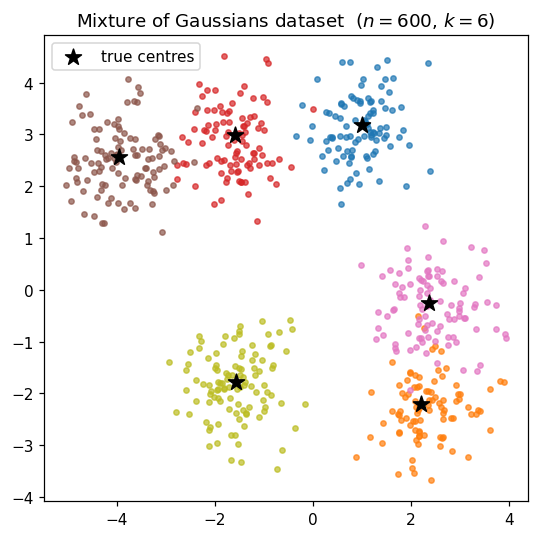

Saved gmm_data.png


In [2]:
def make_gmm(n, k, spread=4.0, sigma=0.6, seed=1):
    rng = np.random.default_rng(seed)
    centres = rng.uniform(-spread, spread, (k, 2))
    labels = rng.integers(0, k, n)
    X = centres[labels] + rng.normal(0, sigma, (n, 2))
    return X, centres, labels

n_pts = 600
k_true = 6
X, true_centres, true_labels = make_gmm(n_pts, k_true, seed=7)

fig, ax = plt.subplots(figsize=(5, 5))
cmap_pts = plt.cm.tab10
for j in range(k_true):
    mask = true_labels == j
    ax.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.7, color=cmap_pts(j / k_true))
ax.scatter(true_centres[:, 0], true_centres[:, 1],
           c='k', s=120, marker='*', zorder=5, label='true centres')
ax.set_title('Mixture of Gaussians dataset  ($n=600$, $k=6$)')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('gmm_data.png', bbox_inches='tight')
plt.close()
print('Saved gmm_data.png')

## Lloyd's algorithm

Each iteration of Lloyd's algorithm:
1. **Assignment**: $z_i = \arg\min_j \|x_i - c_j\|^2$
2. **Update**: $c_j = \frac{1}{|C_j|}\sum_{i: z_i = j} x_i$

The WCSS objective decreases monotonically: both steps are projections onto convex sets in the product space, and convergence (to a local min) is guaranteed in finite iterations.

We implement Lloyd from scratch, recording the objective at every iteration to trace convergence.

In [3]:
def assign(X, centres):
    """Return per-point cluster index and WCSS."""
    dists = np.sum((X[:, None] - centres[None])**2, axis=2)  # (n, k)
    z = np.argmin(dists, axis=1)
    cost = dists[np.arange(len(X)), z].sum()
    return z, cost

def update_centres(X, z, k):
    centres = np.zeros((k, X.shape[1]))
    for j in range(k):
        mask = z == j
        if mask.any():
            centres[j] = X[mask].mean(axis=0)
        else:
            centres[j] = X[np.random.randint(len(X))]
    return centres

def lloyd(X, centres_init, max_iter=100):
    centres = centres_init.copy()
    costs = []
    for _ in range(max_iter):
        z, cost = assign(X, centres)
        costs.append(cost)
        new_centres = update_centres(X, z, len(centres))
        if np.allclose(centres, new_centres):
            break
        centres = new_centres
    z, cost = assign(X, centres)
    costs.append(cost)
    return centres, z, np.array(costs)

## Initialisation strategies

We implement both initialisation methods:

- **Random**: sample $k$ data points uniformly without replacement.
- **K-means++**: pick the first seed uniformly, then iteratively sample subsequent seeds with probability $\propto D(x)^2 = \min_j \|x - c_j\|^2$.

In [4]:
def init_random(X, k, rng):
    idx = rng.choice(len(X), k, replace=False)
    return X[idx].copy()

def init_pp(X, k, rng):
    """K-means++ initialisation."""
    idx = [rng.integers(len(X))]
    for _ in range(k - 1):
        centres = X[idx]
        dists = np.min(
            np.sum((X[:, None] - centres[None])**2, axis=2), axis=1
        )
        probs = dists / dists.sum()
        idx.append(rng.choice(len(X), p=probs))
    return X[np.array(idx)].copy()

## Seed placement comparison

Before running Lloyd, it is instructive to visualise where each initialisation places the $k$ initial seeds. K-means++ seeds should be spread across the data; random seeds may cluster together.

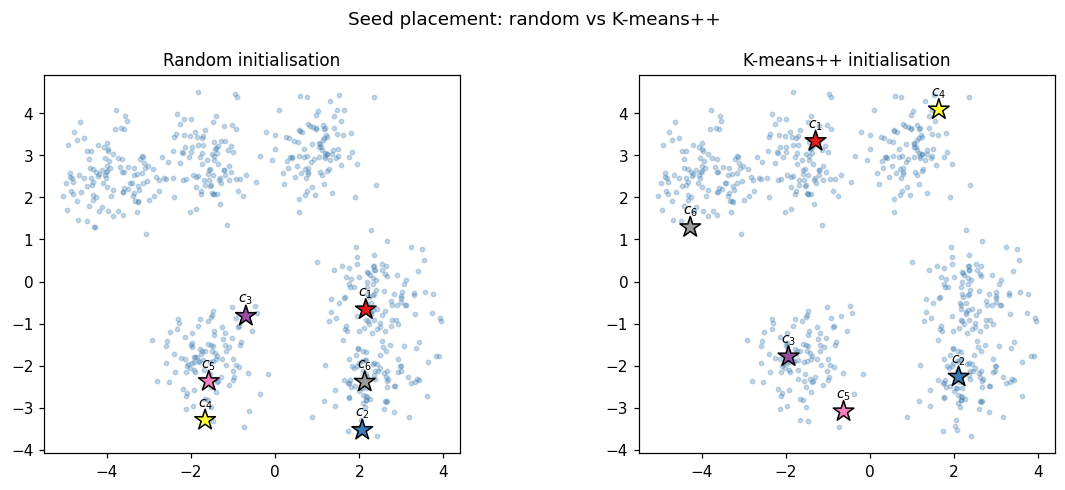

Saved seeds_comparison.png


In [5]:
rng_seed = np.random.default_rng(123)
seeds_rand = init_random(X, k_true, rng_seed)
seeds_pp   = init_pp(X, k_true, rng_seed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, seeds, title in zip(axes,
                              [seeds_rand, seeds_pp],
                              ['Random initialisation', 'K-means++ initialisation']):
    ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.3, color='steelblue')
    ax.scatter(seeds[:, 0], seeds[:, 1],
               c=np.arange(k_true), cmap='Set1',
               s=200, marker='*', edgecolors='k', linewidths=1.0, zorder=5)
    for j, s in enumerate(seeds):
        ax.annotate(f'$c_{j+1}$', s, fontsize=9, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')

fig.suptitle('Seed placement: random vs K-means++', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('seeds_comparison.png', bbox_inches='tight')
plt.close()
print('Saved seeds_comparison.png')

## Convergence curves over multiple restarts

We run 20 independent restarts of each method and plot the WCSS objective as a function of Lloyd iteration. K-means++ restarts should start lower and converge more reliably than random restarts.

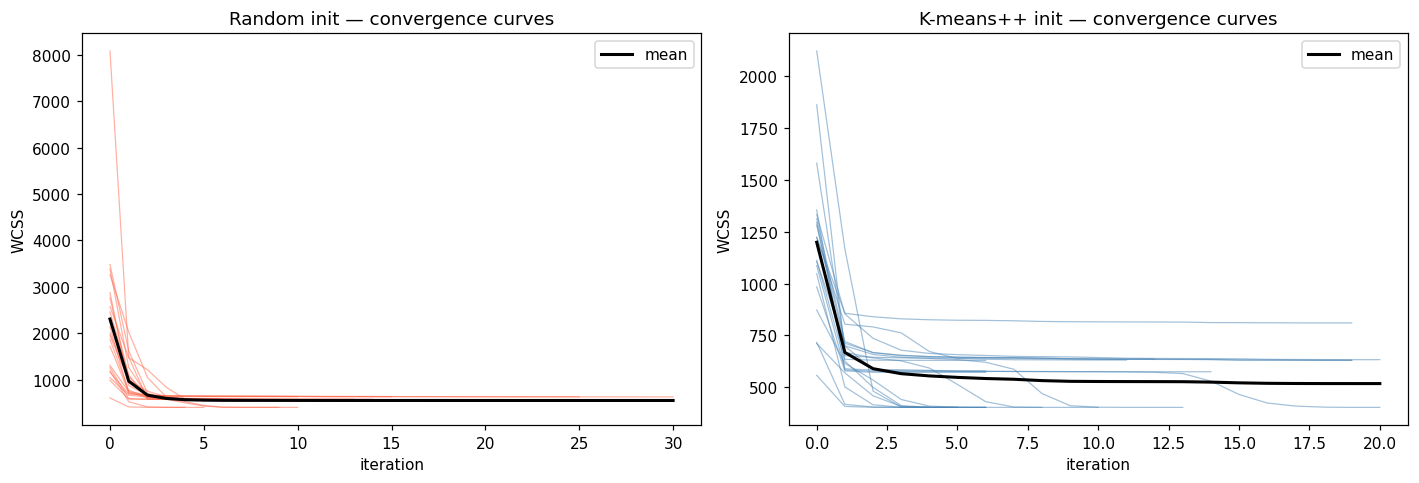

Saved convergence_curves.png


In [6]:
n_restarts = 20
k = k_true
all_costs_rand = []
all_costs_pp   = []
final_rand = []
final_pp   = []

for seed in range(n_restarts):
    rng_r = np.random.default_rng(seed)
    c0_rand = init_random(X, k, rng_r)
    _, _, curve_rand = lloyd(X, c0_rand)
    all_costs_rand.append(curve_rand)
    final_rand.append(curve_rand[-1])

    rng_p = np.random.default_rng(seed + 1000)
    c0_pp = init_pp(X, k, rng_p)
    _, _, curve_pp = lloyd(X, c0_pp)
    all_costs_pp.append(curve_pp)
    final_pp.append(curve_pp[-1])

def mean_curve(curves):
    """Average variable-length convergence curves by edge-padding to max length."""
    max_len = max(len(c) for c in curves)
    M = np.empty((len(curves), max_len))
    for i, c in enumerate(curves):
        M[i] = np.pad(c, (0, max_len - len(c)), mode='edge')
    return M.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for curve in all_costs_rand:
    axes[0].plot(curve, lw=0.8, alpha=0.5, color='tomato')
axes[0].plot(mean_curve(all_costs_rand), 'k-', lw=2, label='mean')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('WCSS')
axes[0].set_title('Random init — convergence curves')
axes[0].legend()

for curve in all_costs_pp:
    axes[1].plot(curve, lw=0.8, alpha=0.5, color='steelblue')
axes[1].plot(mean_curve(all_costs_pp), 'k-', lw=2, label='mean')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('WCSS')
axes[1].set_title('K-means++ init — convergence curves')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig('convergence_curves.png', bbox_inches='tight')
plt.close()
print('Saved convergence_curves.png')

## Distribution of final costs

The histogram of final WCSS values across restarts quantifies the **reliability** of each initialisation. K-means++ should show lower variance and a distribution shifted toward the optimum.

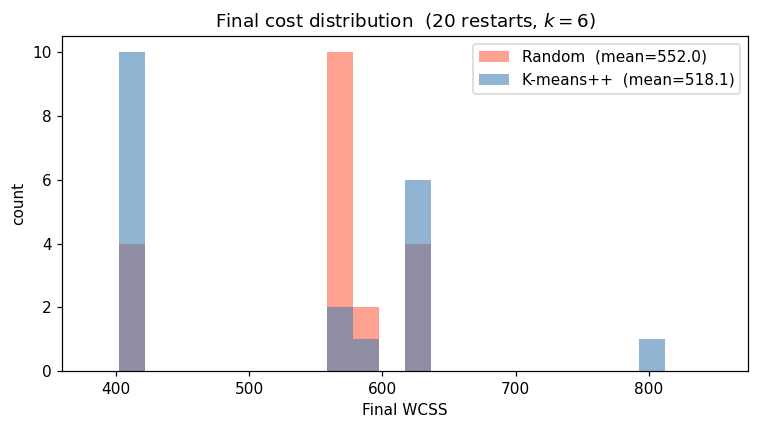

Saved cost_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(min(min(final_rand), min(final_pp)) * 0.95,
                   max(max(final_rand), max(final_pp)) * 1.05, 25)
ax.hist(final_rand, bins=bins, alpha=0.6, color='tomato',    label=f'Random  (mean={np.mean(final_rand):.1f})')
ax.hist(final_pp,   bins=bins, alpha=0.6, color='steelblue', label=f'K-means++  (mean={np.mean(final_pp):.1f})')
ax.set_xlabel('Final WCSS'); ax.set_ylabel('count')
ax.set_title(f'Final cost distribution  ({n_restarts} restarts, $k={k}$)')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('cost_distribution.png', bbox_inches='tight')
plt.close()
print('Saved cost_distribution.png')

## Best clustering result

We select the best K-means++ run (lowest final cost) and visualise the resulting Voronoi partition overlaid on the data.

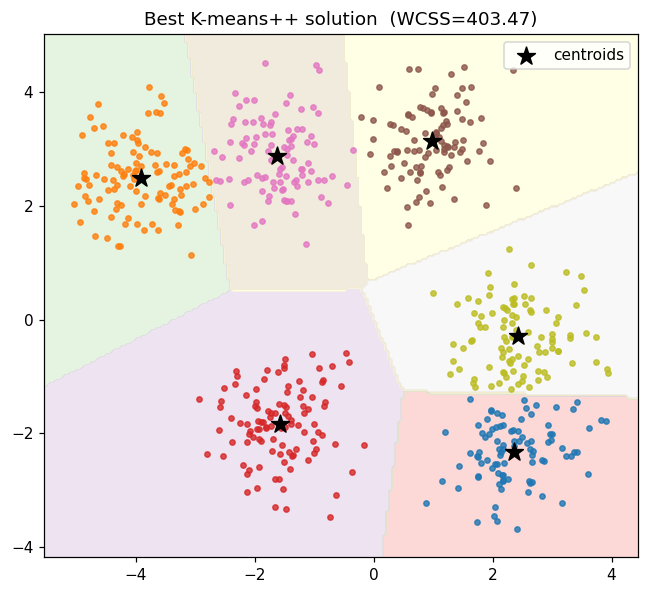

Saved best_clustering.png


In [8]:
best_seed_pp = int(np.argmin(final_pp))
rng_best = np.random.default_rng(best_seed_pp + 1000)
c0_best = init_pp(X, k, rng_best)
centres_best, z_best, _ = lloyd(X, c0_best)

# Voronoi background
xg = np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 200)
yg = np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 200)
Xg, Yg = np.meshgrid(xg, yg)
grid = np.c_[Xg.ravel(), Yg.ravel()]
dg = np.sum((grid[:, None] - centres_best[None])**2, axis=2)
Zg = np.argmin(dg, axis=1).reshape(Xg.shape)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contourf(Xg, Yg, Zg, levels=np.arange(-0.5, k+0.5), cmap='Pastel1', alpha=0.5)
for j in range(k):
    mask = z_best == j
    ax.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.8, color=cmap_pts(j/k))
ax.scatter(centres_best[:, 0], centres_best[:, 1],
           c='k', s=150, marker='*', zorder=5, label='centroids')
ax.set_title(f'Best K-means++ solution  (WCSS={final_pp[best_seed_pp]:.2f})')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('best_clustering.png', bbox_inches='tight')
plt.close()
print('Saved best_clustering.png')

## Interactive: vary $k$ and restart count

The widget below runs both methods for a user-chosen $k$ and displays the distribution of final costs.

## Static snapshot

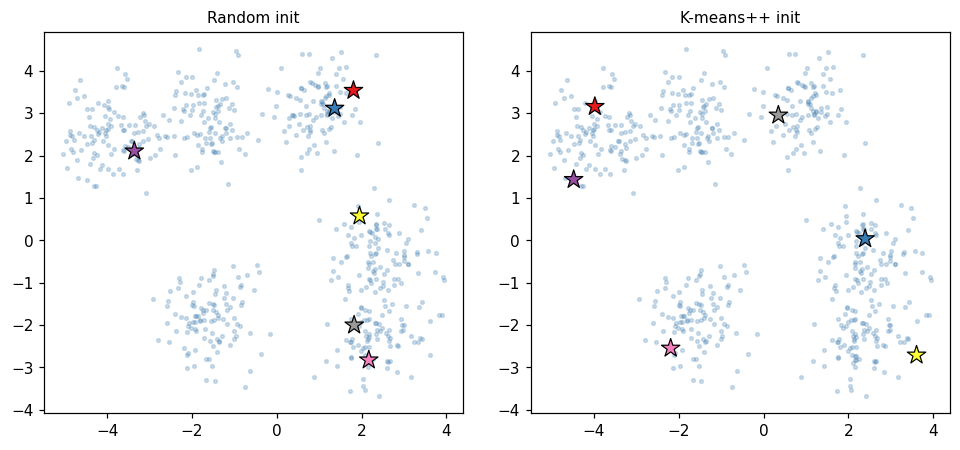

Saved snippet.png


In [9]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    # Seeds
    rng_snap = np.random.default_rng(3)
    s_r = init_random(X, k_true, rng_snap)
    s_p = init_pp(X, k_true, rng_snap)
    for ax, seeds, title in zip(axes, [s_r, s_p],
                                 ['Random init', 'K-means++ init']):
        ax.scatter(X[:, 0], X[:, 1], s=6, alpha=0.25, color='steelblue')
        ax.scatter(seeds[:, 0], seeds[:, 1],
                   c=np.arange(k_true), cmap='Set1',
                   s=160, marker='*', edgecolors='k', linewidths=0.8, zorder=5)
        ax.set_title(title, fontsize=10)
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
    plt.savefig('snippet.png', bbox_inches='tight')
    plt.close()
    print('Saved snippet.png')

## Takeaways

- K-means is a non-convex problem with many local minima; the final quality depends heavily on initialisation.
- K-means++ uses **distance-proportional sampling** to spread seeds, providing an $O(\log k)$ approximation guarantee on the expected cost.
- In practice, K-means++ seeds require fewer Lloyd iterations and produce lower final WCSS with smaller variance across restarts.
- The standard practice is to combine K-means++ with multiple restarts and select the best solution.

## Bibliography

- Arthur, D. and Vassilvitskii, S. (2007). k-means++: The advantages of careful seeding. *SODA 2007*, 1027–1035.
- Lloyd, S. P. (1982). Least squares quantization in PCM. *IEEE Trans. Inf. Theory*, 28(2), 129–137.
- Ostrovsky, R., Rabani, Y., Schulman, L. J., and Swamy, C. (2013). The effectiveness of Lloyd-type methods for the k-means problem. *JACM*, 59(6).
- Celebi, M. E., Kingravi, H. A., and Vela, P. A. (2013). A comparative study of efficient initialization methods for the k-means clustering algorithm. *Expert Systems with Applications*, 40(1), 200–210.